In [443]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [444]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [445]:
def returning_Result(y_train, y_train_pred,y_test,y_pred,NameofTheModel):
    y_train = np.exp(np.ravel(y_train))
    y_train_pred = np.exp(np.ravel(y_train_pred))
    y_test = np.exp(np.ravel(y_test))
    y_pred = np.exp(np.ravel(y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    train_r2   = r2_score(y_train, y_train_pred)
    r2_gap = train_r2 - r2
    if r2_gap > 0.1:
        status = "Overfitting"
    elif r2 < 0.5:
        status = "Underfitting"
    else:
        status = "Good Fit"
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_r2   = r2_score(y_train, y_train_pred)
    return {
        "NameOfModel": NameofTheModel,
        "MAPE" : np.mean(np.abs((np.ravel(y_test) - np.ravel(y_pred)) / y_test)) * 100, #Percentage Error
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R^2": r2,
        "Train_R^2": train_r2,
        "Train_RMSE": train_rmse,
        "R2_Gap": r2_gap,
        "Status": status
    }

In [446]:
df = pd.read_csv("PreEDAVersion.csv")

In [447]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38818 entries, 0 to 38817
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            38818 non-null  int64  
 1   make_model            38818 non-null  object 
 2   trim                  37155 non-null  object 
 3   price                 38818 non-null  float64
 4   mileage               38818 non-null  float64
 5   transmission          37884 non-null  object 
 6   fuel_type             38818 non-null  object 
 7   Year                  38818 non-null  float64
 8   Make                  38818 non-null  object 
 9   Model                 38807 non-null  object 
 10  MoreInformation_x     10948 non-null  object 
 11  Condition             38818 non-null  object 
 12  Age                   38818 non-null  float64
 13  Combined              38818 non-null  object 
 14  no_accidents          38818 non-null  int64  
 15  has_carfax         

In [448]:
#How Many Used Car do we have:
NumberOfNewCars = df[df["Condition"] == "New"].shape[0]
NumberOfUsedCars = df[df["Condition"] == "Used"].shape[0]
print(f"Number of New {NumberOfNewCars} ,,, Number of Used Cars {NumberOfUsedCars}")
print(f"Percentage of New Car in The DataSet {np.round((NumberOfNewCars / (NumberOfNewCars + NumberOfUsedCars)*100))} %" )

Number of New 11810 ,,, Number of Used Cars 27008
Percentage of New Car in The DataSet 30.0 %


In [449]:
#We will only check the usuage of the used cars we dropping the mileage and Price of a New Car.
df.drop(df[df["Condition"]=="New"].index,inplace=True)

In [450]:
df["mileage"].describe()

count     27008.000000
mean      79327.111856
std       62819.183127
min           1.000000
25%       29926.000000
50%       67443.000000
75%      116557.500000
max      398245.000000
Name: mileage, dtype: float64

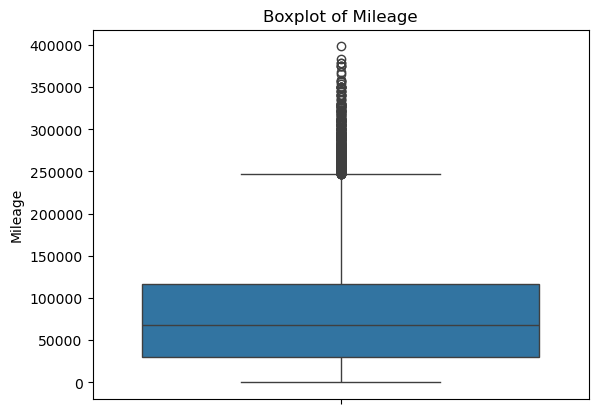

In [451]:
sns.boxplot(y=df["mileage"])
plt.title("Boxplot of Mileage")
plt.ylabel("Mileage")
plt.show()

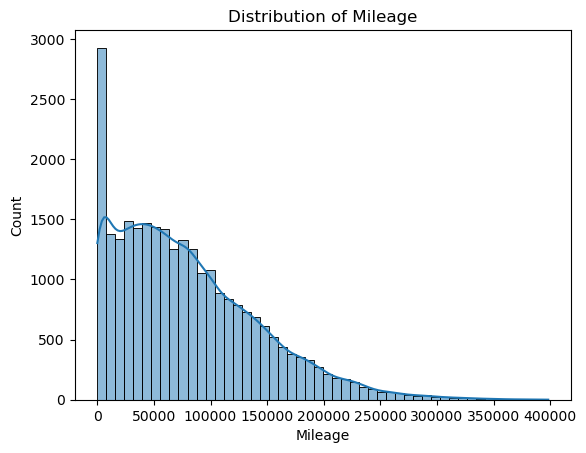

In [452]:
#Mileage
sns.histplot(df["mileage"],bins=50,kde=True)
plt.title("Distribution of Mileage")
plt.xlabel("Mileage")
plt.ylabel("Count")
plt.show()

In [453]:
df["price"].describe()

count     27008.000000
mean      34682.451015
std       20855.072579
min           1.000000
25%       19995.000000
50%       30450.500000
75%       44900.000000
max      135000.000000
Name: price, dtype: float64

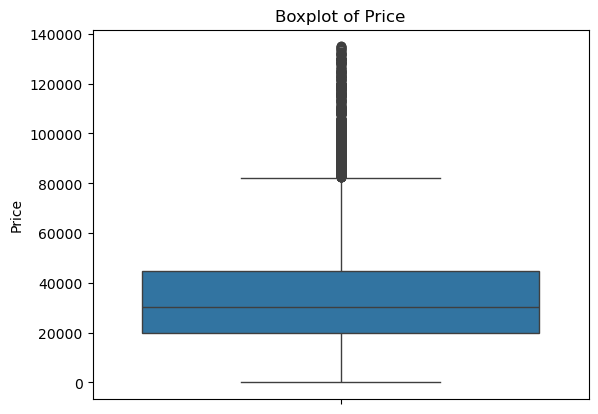

In [454]:
sns.boxplot(y=df["price"])
plt.title("Boxplot of Price")
plt.ylabel("Price")
plt.show()

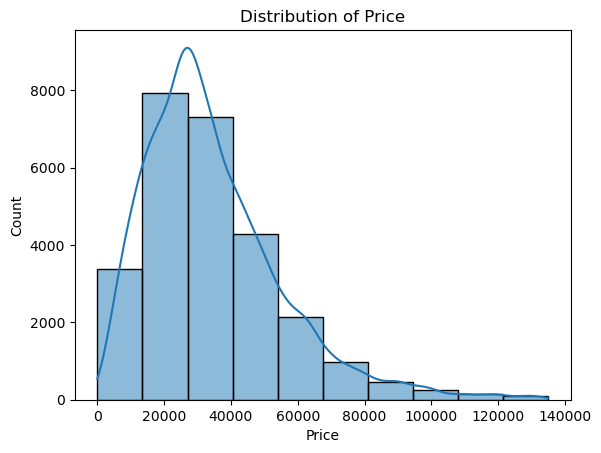

In [455]:

sns.histplot(df["price"],bins=10,kde=True)
plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

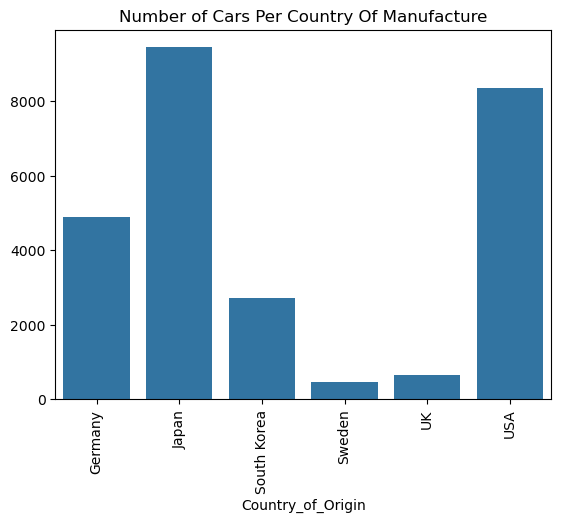

In [456]:
#Number of Cars for each Make:
x=df.groupby(["Country_of_Origin"]).count()["make_model"].index
y=df.groupby(["Country_of_Origin"]).count()["make_model"].values
sns.barplot(x=x,y=y)
plt.title("Number of Cars Per Country Of Manufacture")
plt.xticks(rotation = 90)
plt.show()

In [457]:
model_counts=df["Make"].value_counts()

{"Models":x,"Number of Models":y}
#Finding a Dropping point for our models:
Q1 = model_counts.quantile(0.25)
Q3 = model_counts.quantile(0.75)
IQR = Q3 - Q1

lower_bound = 20
upper_bound = Q3 

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

Q1: 566.75, Q3: 1055.0, IQR: 488.25
Lower bound: 20, Upper bound: 1055.0


In [458]:
low_outliers = model_counts[model_counts < lower_bound]
high_outliers = model_counts[model_counts > upper_bound]

print(f"Models with unusually FEW units ({len(low_outliers)} models):")
print(low_outliers)
print()
print(f"Models with unusually MANY units ({len(high_outliers)} models):")
print(high_outliers)

Models with unusually FEW units (0 models):
Series([], Name: count, dtype: int64)

Models with unusually MANY units (8 models):
Make
Honda         1856
Toyota        1703
Ford          1533
Hyundai       1348
Volkswagen    1249
Nissan        1188
Audi          1122
Mazda         1073
Name: count, dtype: int64


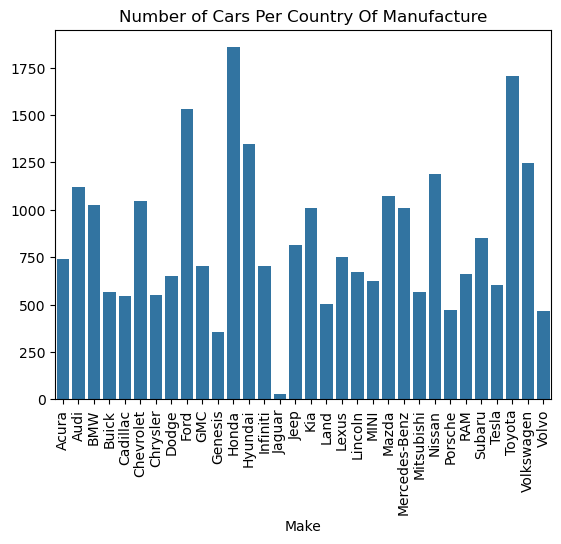

In [459]:
x=df.groupby(["Make"]).count()["make_model"].index
y= df.groupby(["Make"]).count()["make_model"].values
sns.barplot(x=x,y=y)
plt.title("Number of Cars Per Country Of Manufacture")
plt.xticks(rotation = 90)
#plt.figsize()
plt.show()

In [460]:
df.columns

Index(['Unnamed: 0', 'make_model', 'trim', 'price', 'mileage', 'transmission',
       'fuel_type', 'Year', 'Make', 'Model', 'MoreInformation_x', 'Condition',
       'Age', 'Combined', 'no_accidents', 'has_carfax', 'one_owner',
       'service_records', 'certified', 'Engine_Description_x',
       'Package_Description', 'Country_of_Origin', 'Brand_Segment',
       'Engine_Description_y', 'Body Type', 'Cylinders', 'Confidence',
       'Notes'],
      dtype='object')

In [461]:
ElectricCars={"Number of Electric Cars in Fuel_ Type Column":df[df["fuel_type"] == "Electric"].count()["make_model"],"Number of Electric Cars in Cylinders Column":df[df["Cylinders"] == "Electric"].count()["make_model"]}
mismatch_1 = df[(df["fuel_type"] == "Electric") & (df["Cylinders"] != "Electric")]
print(f"Rows where Fuel_type=Electric but Cylinders isn't 0: {len(mismatch_1)}")
print(mismatch_1[["Make", "Model", "fuel_type", "Cylinders"]])

Rows where Fuel_type=Electric but Cylinders isn't 0: 0
Empty DataFrame
Columns: [Make, Model, fuel_type, Cylinders]
Index: []


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'Convertible'),
  Text(1, 0, 'Coupe'),
  Text(2, 0, 'Hatchback'),
  Text(3, 0, 'Minivan'),
  Text(4, 0, 'Pickup Truck'),
  Text(5, 0, 'SUV'),
  Text(6, 0, 'Sedan'),
  Text(7, 0, 'Van'),
  Text(8, 0, 'Wagon')])

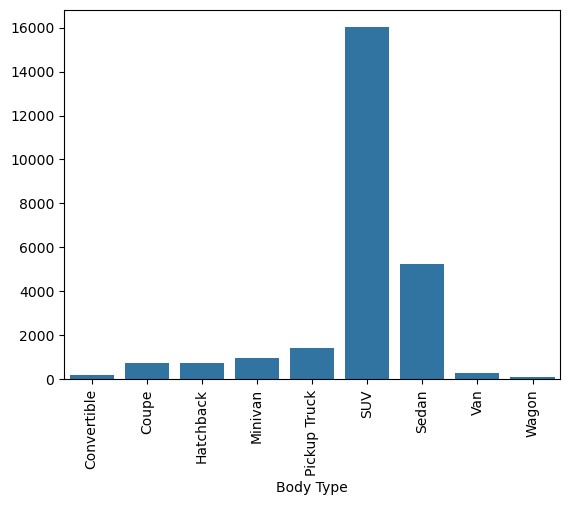

In [462]:
#How Many Car With Diffrenet Body type:
x=df.groupby(["Body Type"]).count()["make_model"].index
y=df.groupby(["Body Type"]).count()["make_model"].values
sns.barplot(x=x,y=y)
plt.xticks(rotation = 90)

<Axes: xlabel='Country_of_Origin'>

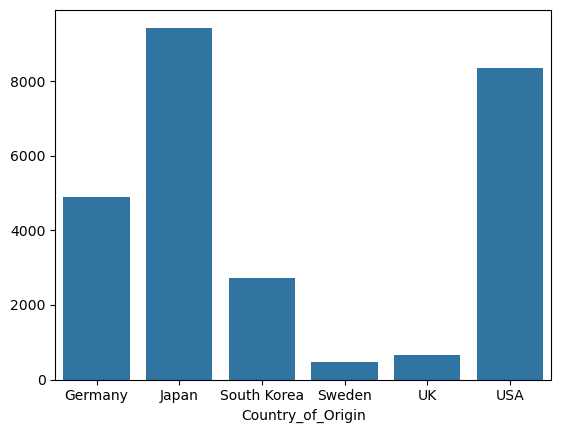

In [463]:
#How many Countries do we have:
x=df.groupby(["Country_of_Origin"]).count()["make_model"].index
y=df.groupby(["Country_of_Origin"]).count()["make_model"].values
sns.barplot(x=x,y=y)

<Axes: xlabel='fuel_type'>

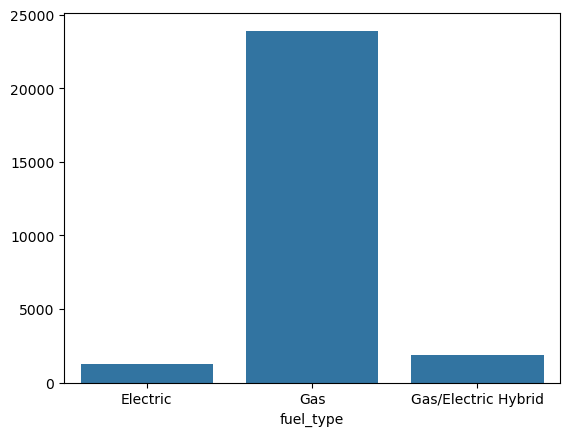

In [464]:
#Checking Fuel Type:
x=df.groupby(["fuel_type"]).count()["make_model"].index
y=df.groupby(["fuel_type"]).count()["make_model"].values
sns.barplot(x=x,y=y)

<Axes: xlabel='Cylinders'>

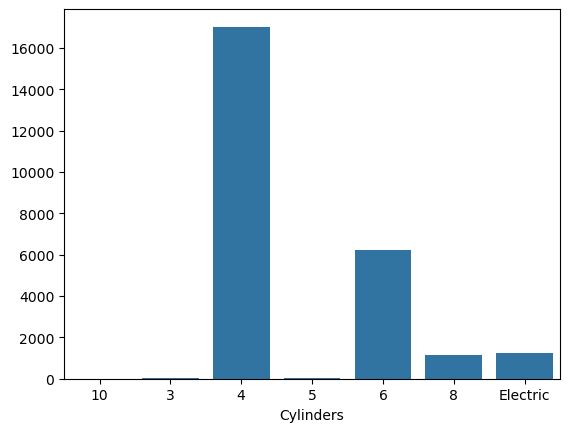

In [465]:
#Number Of Cylinders.
x=df.groupby(["Cylinders"]).count()["make_model"].index
y=df.groupby(["Cylinders"]).count()["make_model"].values
sns.barplot(x=x,y=y)

In [466]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

# Use the SAME subset/rows for both models - this matters for a valid comparison
subset = df.dropna(subset=["price", "mileage", "Age", "Cylinders", "Body Type",
                             "Country_of_Origin", "Brand_Segment", "Make", "Model"])

In [467]:
df[['price','Age','Cylinders','Body Type','Country_of_Origin','Brand_Segment']]

,price,Age,Cylinders,Body Type,Country_of_Origin,Brand_Segment
0,27999.0,5.0,4,SUV,USA,Luxury
4,36998.0,3.0,4,SUV,Japan,Mainstream
5,36888.0,6.0,6,Pickup Truck,USA,Mainstream
6,95985.0,3.0,4,SUV,NaN,NaN
7,35900.0,5.0,6,SUV,Japan,Mainstream
...,...,...,...,...,...,...
38813,18995.0,9.0,4,SUV,Japan,Mainstream
38814,5800.0,15.0,4,Sedan,Japan,Mainstream
38815,42995.0,5.0,4,SUV,Japan,Luxury
38816,26995.0,9.0,6,Coupe,Germany,Luxury


In [468]:
df[['price','mileage','Age','Make','Model']]

,price,mileage,Age,Make,Model
0,27999.0,109941.0,5.0,Lincoln,Corsair
4,36998.0,38480.0,3.0,Mazda,CX-5
5,36888.0,148579.0,6.0,Ford,F-150
6,95985.0,53956.0,3.0,Land,Rover
7,35900.0,73789.0,5.0,Honda,Passport
...,...,...,...,...,...
38813,18995.0,131300.0,9.0,Subaru,Forester
38814,5800.0,172000.0,15.0,Nissan,Sentra
38815,42995.0,64028.0,5.0,Lexus,RX
38816,26995.0,198000.0,9.0,Audi,A5


In [469]:
# Model A: generic/category-based (your hypothesis - rivals price the same)
model_generic = smf.ols(
    'price ~ mileage + Age + C(Cylinders) + Q("Body Type") + C(Country_of_Origin) + C(Brand_Segment)',
    data=subset
).fit()

# Model B: everything in Model A, PLUS specific Make/Model identity
model_specific = smf.ols(
    'price ~ mileage + Age + C(Cylinders) + Q("Body Type") + C(Country_of_Origin) + C(Brand_Segment) + C(Make) + C(Model)',
    data=subset
).fit()

print("=== Model A (Generic: Cylinders, Body Type, Country, Segment) ===")
print(f"R²: {model_generic.rsquared:.4f}")
print(f"Adjusted R²: {model_generic.rsquared_adj:.4f}")
print()
print("=== Model B (Specific: + Make, Model) ===")
print(f"R²: {model_specific.rsquared:.4f}")
print(f"Adjusted R²: {model_specific.rsquared_adj:.4f}")

=== Model A (Generic: Cylinders, Body Type, Country, Segment) ===
R²: 0.6721
Adjusted R²: 0.6718

=== Model B (Specific: + Make, Model) ===
R²: 0.8147
Adjusted R²: 0.8113


In [ ]:
# Target encoding: replace each Make with the average price for that Make
make_avg_price = df.groupby("Make")["price"].mean()
df["Make_avg_price"] = df["Make"].map(make_avg_price)

# Same for Model, if you want that granularity too
model_avg_price = df.groupby("Model")["price"].mean()
df["Model_avg_price"] = df["Model"].map(model_avg_price)
print(f"Make Average Price is {make_avg_price}")
print("====")
print(f"Model Average Price is {model_avg_price}")

In [470]:
model=df.drop(columns=["Unnamed: 0","make_model","Condition","trim","Make","Model","MoreInformation_x","Year","Combined","Engine_Description_x","Confidence","Engine_Description_y","Package_Description","Notes"])

In [471]:
model.dropna(subset=["transmission","Cylinders","Country_of_Origin","Brand_Segment"],inplace=True)

In [472]:
model.columns

Index(['price', 'mileage', 'transmission', 'fuel_type', 'Age', 'no_accidents',
       'has_carfax', 'one_owner', 'service_records', 'certified',
       'Country_of_Origin', 'Brand_Segment', 'Body Type', 'Cylinders'],
      dtype='object')

In [473]:
print(model.isna().sum())

price                 0
mileage               0
transmission          0
fuel_type             0
Age                   0
no_accidents          0
has_carfax            0
one_owner             0
service_records       0
certified             0
Country_of_Origin     0
Brand_Segment         0
Body Type            17
Cylinders             0
dtype: int64


In [474]:
model = pd.get_dummies(model, columns=["Country_of_Origin", "Brand_Segment","Body Type","transmission","fuel_type"], drop_first=True, dtype=int)

In [475]:
model.loc[df["Cylinders"] == "Electric", "Cylinders"] = 0
model["Cylinders"] = pd.to_numeric(model["Cylinders"], errors="coerce")

In [476]:
model.dropna(inplace=True)
X=model.drop(columns=["price"])
y = np.log(model[["price"]])
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=2, test_size=0.3,shuffle=True)

In [477]:
X_train.columns

Index(['mileage', 'Age', 'no_accidents', 'has_carfax', 'one_owner',
       'service_records', 'certified', 'Cylinders', 'Country_of_Origin_Japan',
       'Country_of_Origin_South Korea', 'Country_of_Origin_Sweden',
       'Country_of_Origin_UK', 'Country_of_Origin_USA', 'Brand_Segment_Luxury',
       'Brand_Segment_Mainstream', 'Brand_Segment_Near-luxury',
       'Brand_Segment_Premium', 'Body Type_Coupe', 'Body Type_Hatchback',
       'Body Type_Minivan', 'Body Type_Pickup Truck', 'Body Type_SUV',
       'Body Type_Sedan', 'Body Type_Van', 'Body Type_Wagon',
       'transmission_Manual', 'fuel_type_Gas',
       'fuel_type_Gas/Electric Hybrid'],
      dtype='object')

In [478]:
results_list=[]
reg_all = LinearRegression()
reg_all.fit(X_train,y_train)
y_pred = reg_all.predict(X_test)
y_pred_test = reg_all.predict(X_train)
results_list.append(returning_Result(y_train,y_pred_test,y_test, y_pred, "LinearRegression"))

In [479]:
dt = DecisionTreeRegressor(max_depth=4,random_state=2)
dt.fit(X_train,y_train)
y_pred = dt.predict(X_test)
y_train_pred = dt.predict(X_train)
results_list.append(returning_Result(y_train,y_train_pred,y_test, y_pred, "DecisionTreeRegressor"))

In [480]:
df

,Unnamed: 0,make_model,trim,price,mileage,transmission,fuel_type,Year,Make,Model,...,certified,Engine_Description_x,Package_Description,Country_of_Origin,Brand_Segment,Engine_Description_y,Body Type,Cylinders,Confidence,Notes
0,0,2022 Lincoln Corsair,NaN,27999.0,109941.0,Automatic,Gas,2022.0,Lincoln,Corsair,...,0,NaN,NaN,USA,Luxury,NaN,SUV,4,Medium,NaN
4,4,2024 Mazda CX-5,Suna AWD/CLEAN CARFAX/LOW MILEAGE/SERVICE RECORD,36998.0,38480.0,Automatic,Gas,2024.0,Mazda,CX-5,...,0,NaN,NaN,Japan,Mainstream,NaN,SUV,4,Medium,NaN
5,5,2021 Ford F-150,XLT|BANG & OLUFSEN|CARPLAY|LANE KEEP ASSIST|NAV,36888.0,148579.0,Automatic,Gas,2021.0,Ford,F-150,...,0,NaN,XLT,USA,Mainstream,NaN,Pickup Truck,6,Medium,NaN
6,6,2024 Land Rover Defender,110 P525 V8,95985.0,53956.0,Automatic,Gas,2024.0,Land,Rover,...,0,NaN,NaN,NaN,NaN,NaN,SUV,4,High,NaN
7,7,2022 Honda Passport,TrailSport,35900.0,73789.0,Automatic,Gas,2022.0,Honda,Passport,...,0,NaN,TrailSport,Japan,Mainstream,NaN,SUV,6,Medium,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38813,38905,2018 Subaru Forester,2.0XT Touring CVT,18995.0,131300.0,Automatic,Gas,2018.0,Subaru,Forester,...,0,NaN,Touring,Japan,Mainstream,NaN,SUV,4,Medium,NaN
38814,38906,2012 Nissan Sentra,NaN,5800.0,172000.0,Automatic,Gas,2012.0,Nissan,Sentra,...,0,NaN,NaN,Japan,Mainstream,NaN,Sedan,4,Medium,NaN
38815,38907,2022 Lexus RX,"Premium AWD, Back Up Cam, Sunroof, Bluetooth",42995.0,64028.0,Automatic,Gas,2022.0,Lexus,RX,...,0,NaN,NaN,Japan,Luxury,F,SUV,4,High,NaN
38816,38908,2018 Audi A5 Cabriolet,Technik,26995.0,198000.0,Automatic,Gas,2018.0,Audi,A5,...,0,NaN,Technik,Germany,Luxury,"Quattro, TFSI",Coupe,6,High,NaN


In [481]:
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": dt.feature_importances_
}).sort_values("importance", ascending=False)

print(importances)

                          feature  importance
1                             Age    0.626565
0                         mileage    0.218428
7                       Cylinders    0.116579
13           Brand_Segment_Luxury    0.038427
3                      has_carfax    0.000000
4                       one_owner    0.000000
5                 service_records    0.000000
6                       certified    0.000000
8         Country_of_Origin_Japan    0.000000
9   Country_of_Origin_South Korea    0.000000
10       Country_of_Origin_Sweden    0.000000
2                    no_accidents    0.000000
11           Country_of_Origin_UK    0.000000
12          Country_of_Origin_USA    0.000000
14       Brand_Segment_Mainstream    0.000000
15      Brand_Segment_Near-luxury    0.000000
16          Brand_Segment_Premium    0.000000
17                Body Type_Coupe    0.000000
18            Body Type_Hatchback    0.000000
19              Body Type_Minivan    0.000000
20         Body Type_Pickup Truck 

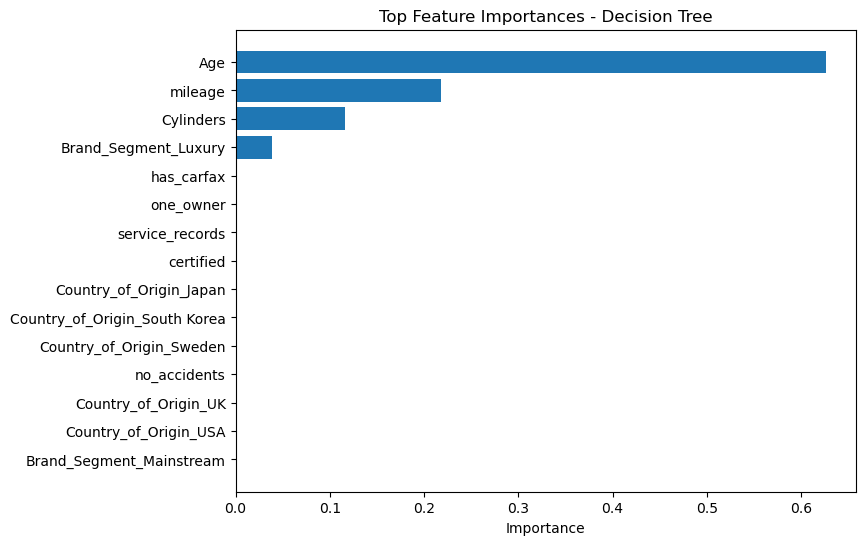

In [482]:
top_n = 15  # adjust based on how many features you have
top_features = importances.head(top_n)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importance")
plt.title("Top Feature Importances - Decision Tree")
plt.gca().invert_yaxis()  # highest importance at top
plt.show()

In [483]:
sgbt = GradientBoostingRegressor(
    max_depth=4,
    n_estimators=600,
    subsample=0.8,
    max_features=1,
    learning_rate=0.1,
    random_state=1
)
sgbt.fit(X_train, y_train)
y_pred = sgbt.predict(X_test)
y_train_pred=sgbt.predict(X_train)
results_list.append(returning_Result(y_train,y_train_pred,y_test, y_pred, "GradientBoostingRegressor"))

c:\Users\moham\anaconda3\Lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


In [484]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    max_depth=5,             # deeper → capture more interactions
    n_estimators=2000,       # more trees (early stopping will cut it down)
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=1,    # let trees see most columns
    min_child_weight=3,      # mild regularization for the sparse dummies
    reg_lambda=1.0,
    random_state=1,
    n_jobs=-1
)
xgb.fit(X_train, y_train)

y_pred       = xgb.predict(X_test)
y_train_pred = xgb.predict(X_train)

results_list.append(returning_Result(y_train, y_train_pred, y_test, y_pred, "XGBoostRegressor"))

In [485]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "alpha": [0.001,0.05,0.01,0.1,10]
}

ridge = Ridge()

ridge_cv = GridSearchCV(ridge, param_grid, cv=kf)

ridge_cv.fit(X_train, y_train)

y_pred = ridge_cv.predict(X_test)
y_pred_train = ridge_cv.predict(X_train)

print(ridge_cv.best_params_, ridge_cv.best_score_)

results_list.append(
    returning_Result(y_train, y_pred_train, y_test, y_pred, "Ridge Regression")
)

{'alpha': 0.1} 0.7983483125364854


In [486]:
print(np.mean(np.exp(y_pred)))

33488.15320549343


In [487]:
errors = pd.Series(
    np.exp(np.asarray(y_test).ravel()) -
    np.exp(np.asarray(y_pred).ravel()),
    index=y_test.index,
    name="prediction_error"
)
comparison = pd.DataFrame({
    "actual_price": np.exp(np.asarray(y_test).ravel()),
    "predicted_price": np.exp(np.asarray(y_pred).ravel()),
    "error": errors
}, index=y_test.index)

print(np.mean(errors))

962.8557721295109


                          feature  importance
1                             Age    0.201573
13           Brand_Segment_Luxury    0.125031
7                       Cylinders    0.106314
26                  fuel_type_Gas    0.066128
20         Body Type_Pickup Truck    0.063591
0                         mileage    0.051678
11           Country_of_Origin_UK    0.045400
22                Body Type_Sedan    0.032852
9   Country_of_Origin_South Korea    0.031572
19              Body Type_Minivan    0.029575
8         Country_of_Origin_Japan    0.027572
17                Body Type_Coupe    0.027289
18            Body Type_Hatchback    0.022650
14       Brand_Segment_Mainstream    0.020140
12          Country_of_Origin_USA    0.019184
25            transmission_Manual    0.016545
27  fuel_type_Gas/Electric Hybrid    0.014532
15      Brand_Segment_Near-luxury    0.013748
23                  Body Type_Van    0.011996
16          Brand_Segment_Premium    0.011572
21                  Body Type_SUV 

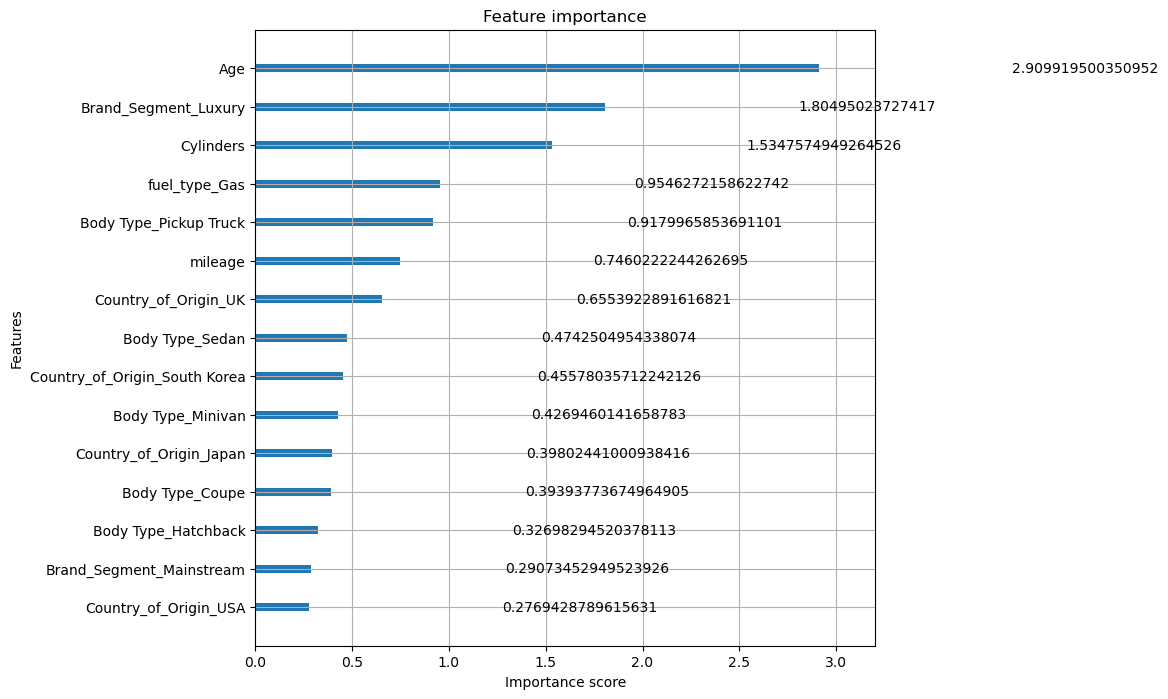

In [488]:
importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)
from xgboost import plot_importance
print(importances)

fig, ax = plt.subplots(figsize=(8, 8))
plot_importance(xgb, importance_type="gain", max_num_features=15, ax=ax)
plt.show()

In [489]:
pd.DataFrame(results_list)

,NameOfModel,MAPE,MAE,MSE,RMSE,R^2,Train_R^2,Train_RMSE,R2_Gap,Status
0,LinearRegression,26.742399,6589.179207,1.099260e+08,10484.559434,0.739558,0.741890,10374.348092,0.002331,Good Fit
1,DecisionTreeRegressor,33.238549,8651.363096,1.662858e+08,12895.183471,0.606028,0.601533,12890.039752,-0.004496,Good Fit
2,GradientBoostingRegressor,23.221144,5694.616844,8.585763e+07,9265.939010,0.796582,0.820425,8653.291228,0.023842,Good Fit
3,XGBoostRegressor,22.172236,5378.179802,7.870289e+07,8871.465074,0.813534,0.888358,6822.939961,0.074825,Good Fit
4,Ridge Regression,26.741680,6588.926963,1.099220e+08,10484.369618,0.739568,0.741894,10374.265944,0.002326,Good Fit


In [490]:
X_train

,mileage,Age,no_accidents,has_carfax,one_owner,service_records,certified,Cylinders,Country_of_Origin_Japan,Country_of_Origin_South Korea,...,Body Type_Hatchback,Body Type_Minivan,Body Type_Pickup Truck,Body Type_SUV,Body Type_Sedan,Body Type_Van,Body Type_Wagon,transmission_Manual,fuel_type_Gas,fuel_type_Gas/Electric Hybrid
17071,90.0,0.0,0,0,0,0,0,4,0,0,...,0,0,0,1,0,0,0,0,1,0
37067,69697.0,5.0,0,0,0,0,0,6,0,0,...,1,0,0,0,0,0,0,0,1,0
28311,113547.0,7.0,0,0,0,0,0,4,1,0,...,0,0,0,1,0,0,0,0,1,0
38048,177556.0,12.0,1,0,0,0,1,4,0,0,...,1,0,0,0,0,0,0,0,1,0
35612,21908.0,5.0,0,0,0,0,0,4,0,0,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30084,246157.0,15.0,0,0,0,0,0,4,0,0,...,0,0,0,0,1,0,0,0,1,0
19393,82950.0,9.0,0,0,0,0,0,4,1,0,...,0,0,0,1,0,0,0,0,1,0
10276,4724.0,1.0,0,0,0,0,0,8,0,0,...,0,0,1,0,0,0,0,0,1,0
3919,57615.0,4.0,0,0,0,0,0,6,1,0,...,0,0,0,1,0,0,0,0,1,0
